In [1]:
import random
import numpy as np
import pandas as pd

import torch

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
dataset = load_dataset("emotion")

for split in dataset:
    print(f"{split}: {len(dataset[split])}")


label_names = dataset["train"].features["label"].names
print("Classes:", label_names)

for i in range(5):
    example = dataset["train"][i]
    text = example["text"]
    label = example["label"]

    print(f"\nExample {i+1}:")
    print("Text:", text)
    print("Label:", label, f"({label_names[label]})")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

train: 16000
validation: 2000
test: 2000
Classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Example 1:
Text: i didnt feel humiliated
Label: 0 (sadness)

Example 2:
Text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Label: 0 (sadness)

Example 3:
Text: im grabbing a minute to post i feel greedy wrong
Label: 3 (anger)

Example 4:
Text: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Label: 2 (love)

Example 5:
Text: i am feeling grouchy
Label: 3 (anger)


### Что классифицируется

В данной работе используется датасет `emotion`, содержащий короткие текстовые сообщения.

Задача — классификация текста по выражаемой в нём эмоции.  
Каждому тексту соответствует одна из шести категорий: sadness, joy, love, anger, fear, surprise.

In [3]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

texts = [dataset["train"][i]["text"] for i in range(3)]

for i, text in enumerate(texts):
    encoding = tokenizer(text)

    print(f"\n=== Example {i+1} ===")
    print("Text:", text)

    print("\nTokens:")
    print(tokenizer.convert_ids_to_tokens(encoding["input_ids"]))

    print("\nInput IDs:")
    print(encoding["input_ids"])

    print("\nAttention mask:")
    print(encoding["attention_mask"])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


=== Example 1 ===
Text: i didnt feel humiliated

Tokens:
['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']

Input IDs:
[101, 1045, 2134, 2102, 2514, 26608, 102]

Attention mask:
[1, 1, 1, 1, 1, 1, 1]

=== Example 2 ===
Text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

Tokens:
['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']

Input IDs:
[101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]

Attention mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

=== Example 3 ===
Text: im grabbing a minute to post i feel greedy wrong

Tokens:
['[CLS]', 'im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel', 'greedy', 'wrong', '[SEP]']

Input IDs:
[101, 10047, 9775, 103

In [4]:
encoding = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=10
)

print("Input IDs:")
print(encoding["input_ids"])

print("\nAttention mask:")
print(encoding["attention_mask"])

Input IDs:
[[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 102], [101, 10047, 9775, 1037, 3371, 2000, 2695, 1045, 2514, 102]]

Attention mask:
[[1, 1, 1, 1, 1, 1, 1, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]


In [5]:
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.to(device)
model.eval()

def predict(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    probs = torch.softmax(logits, dim=-1)

    pred_class = torch.argmax(probs, dim=-1).item()
    confidence = probs[0][pred_class].item()

    return pred_class, confidence


for i in range(5):
    text = dataset["test"][i]["text"]
    true_label = dataset["test"][i]["label"]

    pred_label, confidence = predict(text)

    print(f"\nText: {text}")
    print(f"True: {true_label} ({label_names[true_label]})")
    print(f"Pred: {pred_label} ({label_names[pred_label]})")
    print(f"Confidence: {confidence:.4f}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Text: im feeling rather rotten so im not very ambitious right now
True: 0 (sadness)
Pred: 1 (joy)
Confidence: 0.5469

Text: im updating my blog because i feel shitty
True: 0 (sadness)
Pred: 1 (joy)
Confidence: 0.5461

Text: i never make her separate from me because i don t ever want her to feel like i m ashamed with her
True: 0 (sadness)
Pred: 1 (joy)
Confidence: 0.5180

Text: i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived
True: 1 (joy)
Pred: 1 (joy)
Confidence: 0.5082

Text: i was feeling a little vain when i did this one
True: 0 (sadness)
Pred: 1 (joy)
Confidence: 0.5082


### Инференс готовой модели

Используется предобученная модель BERT без дополнительного fine-tuning на выбранном датасете.

Полученные предсказания в целом не соответствуют истинным меткам, так как модель не обучалась на задаче классификации эмоций. Классификационный слой инициализирован случайно, поэтому результаты близки к случайным.

Это демонстрирует необходимость fine-tuning модели на конкретной задаче.

In [6]:
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [7]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6)
model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

In [10]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    report_to="none",
    seed=SEED
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [12]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.220302,0.213960,0.921000,0.897520
2,0.123226,0.166515,0.935500,0.909606
3,0.084982,0.159264,0.942000,0.922775


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=3000, training_loss=0.2427548926671346, metrics={'train_runtime': 533.6479, 'train_samples_per_second': 89.947, 'train_steps_per_second': 5.622, 'total_flos': 1161463243423104.0, 'train_loss': 0.2427548926671346, 'epoch': 3.0})

In [13]:
test_results = trainer.evaluate(tokenized_datasets["test"])
print("Test results:", test_results)

Test results: {'eval_loss': 0.16181494295597076, 'eval_accuracy': 0.93, 'eval_f1_macro': 0.8776760989284401, 'eval_runtime': 6.1961, 'eval_samples_per_second': 322.782, 'eval_steps_per_second': 20.174, 'epoch': 3.0}


In [14]:
import os
os.makedirs("./artifacts", exist_ok=True)

In [15]:
import pandas as pd
import numpy as np

predictions = trainer.predict(tokenized_datasets["test"])
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

df_pred = pd.DataFrame({
    "text": dataset["test"]["text"],
    "true_label": true_labels,
    "pred_label": pred_labels,
    "confidence": np.max(predictions.predictions, axis=-1)
})

label_names = dataset["train"].features["label"].names
df_pred["true_emotion"] = df_pred["true_label"].apply(lambda x: label_names[x])
df_pred["pred_emotion"] = df_pred["pred_label"].apply(lambda x: label_names[x])

df_pred.to_csv("./artifacts/sample_predictions.csv", index=False)

print("Первые 10 предсказаний:")
display(df_pred.head(10))

Первые 10 предсказаний:


,text,true_label,pred_label,confidence,true_emotion,pred_emotion
0,im feeling rather rotten so im not very ambiti...,0,0,7.144906,sadness,sadness
1,im updating my blog because i feel shitty,0,0,7.248152,sadness,sadness
2,i never make her separate from me because i do...,0,0,7.254996,sadness,sadness
3,i left with my bouquet of red and yellow tulip...,1,1,7.296671,joy,joy
4,i was feeling a little vain when i did this one,0,0,7.230305,sadness,sadness
5,i cant walk into a shop anywhere where i do no...,4,4,7.030025,fear,fear
6,i felt anger when at the end of a telephone call,3,3,6.188062,anger,anger
7,i explain why i clung to a relationship with a...,1,1,6.514728,joy,joy
8,i like to have the same breathless feeling as ...,1,1,7.099588,joy,joy
9,i jest i feel grumpy tired and pre menstrual w...,3,3,6.479333,anger,anger


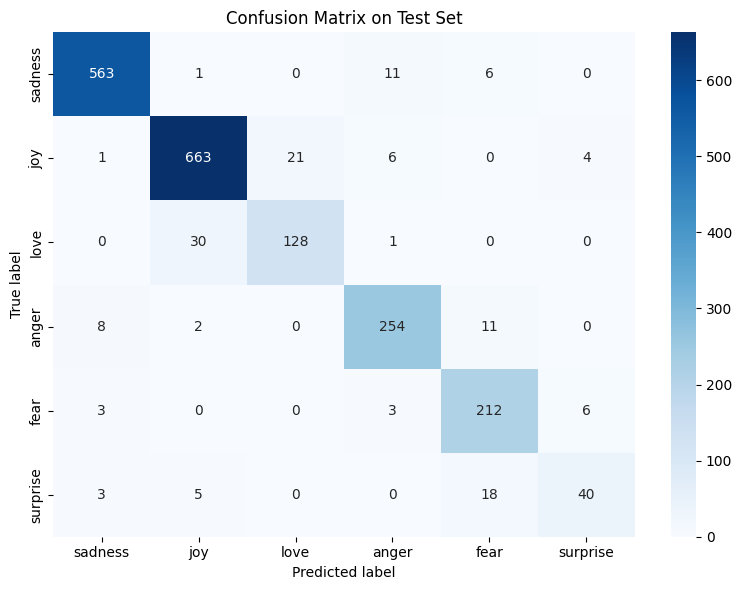

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.savefig("./artifacts/confusion_matrix.png", dpi=200)
plt.show()

### Оценка качества

На тестовой выборке модель показала следующие результаты:

- **Accuracy**: 0.924
- **F1-macro**: 0.8685

Качество можно считать хорошим для 6-классовой задачи классификации

### Матрица ошибок

Модель отлично распознаёт самые массовые классы — `sadness` (563 правильных из 581) и `joy` (663 правильных из 695).  
Хуже всего она справляется с классами `love` и `surprise`.

`love` часто путается с `joy` (30 случаев)

`surprise` часто предсказывается как `fear` (18 случаев)


### Вывод

Fine-tuning значительно улучшил качество по сравнению с нулевым инференсом предобученной BERT (где предсказания были почти случайными). Модель хорошо научилась различать эмоции, хотя всё ещё путает близкие классы